In [62]:
!pip install pandas matplotlib seaborn folium

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

In [64]:
# If you want to read the CSV file using pandas
import pandas as pd

# Read the CSV file (make sure the file is in the correct directory)
df = pd.read_csv('Meteorite_Landings.csv')

# Display the first few rows of the data
print(df.head())

# Alternative: If you just want to reference the filenames as strings
notebook_file = 'Meteorite_Project.ipynb'
csv_file = 'Meteorite_Landings.csv'
print(f"Notebook file: {notebook_file}")
print(f"Data file: {csv_file}")

       name   id nametype     recclass  mass (g)  fall    year    reclat  \
0    Aachen    1    Valid           L5      21.0  Fell  1880.0  50.77500   
1    Aarhus    2    Valid           H6     720.0  Fell  1951.0  56.18333   
2      Abee    6    Valid          EH4  107000.0  Fell  1952.0  54.21667   
3  Acapulco   10    Valid  Acapulcoite    1914.0  Fell  1976.0  16.88333   
4   Achiras  370    Valid           L6     780.0  Fell  1902.0 -33.16667   

     reclong           GeoLocation  
0    6.08333     (50.775, 6.08333)  
1   10.23333  (56.18333, 10.23333)  
2 -113.00000    (54.21667, -113.0)  
3  -99.90000     (16.88333, -99.9)  
4  -64.95000   (-33.16667, -64.95)  
Notebook file: Meteorite_Project.ipynb
Data file: Meteorite_Landings.csv


In [65]:
import pandas as pd

df = pd.read_csv("Meteorite_Landings.csv")
df.head()


,name,id,nametype,recclass,mass (g),fall,year,reclat,reclong,GeoLocation
0,Aachen,1,Valid,L5,21.0,Fell,1880.0,50.77500,6.08333,"(50.775, 6.08333)"
1,Aarhus,2,Valid,H6,720.0,Fell,1951.0,56.18333,10.23333,"(56.18333, 10.23333)"
2,Abee,6,Valid,EH4,107000.0,Fell,1952.0,54.21667,-113.00000,"(54.21667, -113.0)"
3,Acapulco,10,Valid,Acapulcoite,1914.0,Fell,1976.0,16.88333,-99.90000,"(16.88333, -99.9)"
4,Achiras,370,Valid,L6,780.0,Fell,1902.0,-33.16667,-64.95000,"(-33.16667, -64.95)"


In [66]:
df.isnull().sum()

name              0
id                0
nametype          0
recclass          0
mass (g)        131
fall              0
year            291
reclat         7315
reclong        7315
GeoLocation    7315
dtype: int64

In [67]:
df = df.dropna(subset=["mass (g)", "year", "reclat", "reclong"])

In [68]:
df = df.copy()

df.loc[:, "year"] = pd.to_datetime(df["year"], errors='coerce')
df.loc[:, "mass (g)"] = pd.to_numeric(df["mass (g)"], errors='coerce')

C:\Users\SAKSHAM\AppData\Local\Temp\ipykernel_18056\1050801289.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '<DatetimeArray>
['1970-01-01 00:00:00.000001880', '1970-01-01 00:00:00.000001951',
 '1970-01-01 00:00:00.000001952', '1970-01-01 00:00:00.000001976',
 '1970-01-01 00:00:00.000001902', '1970-01-01 00:00:00.000001919',
 '1970-01-01 00:00:00.000001949', '1970-01-01 00:00:00.000001814',
 '1970-01-01 00:00:00.000001930', '1970-01-01 00:00:00.000001920',
 ...
 '1970-01-01 00:00:00.000001956', '1970-01-01 00:00:00.000001983',
 '1970-01-01 00:00:00.000001966', '1970-01-01 00:00:00.000001981',
 '1970-01-01 00:00:00.000001990', '1970-01-01 00:00:00.000001990',
 '1970-01-01 00:00:00.000001999', '1970-01-01 00:00:00.000001939',
 '1970-01-01 00:00:00.000002003', '1970-01-01 00:00:00.000001976']
Length: 38115, dtype: datetime64[ns]' has dtype incompatible with float64, please explicitly cast to a compatible dtype fi

In [69]:

df = df.dropna()

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38115 entries, 0 to 45715
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   name         38115 non-null  object        
 1   id           38115 non-null  int64         
 2   nametype     38115 non-null  object        
 3   recclass     38115 non-null  object        
 4   mass (g)     38115 non-null  float64       
 5   fall         38115 non-null  object        
 6   year         38115 non-null  datetime64[ns]
 7   reclat       38115 non-null  float64       
 8   reclong      38115 non-null  float64       
 9   GeoLocation  38115 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(5)
memory usage: 3.2+ MB


In [71]:
df["century"] = (df["year"].dt.year // 100 + 1)

In [72]:
df["mass (g)"].mean()
df["mass (g)"].max()
df["mass (g)"].median()

29.09

In [73]:


df["fall"].value_counts()
df.groupby("fall")["mass (g)"].mean()

fall
Fell     47506.128685
Found    14683.586091
Name: mass (g), dtype: float64

In [74]:
df["fall"].value_counts()

fall
Found    37050
Fell      1065
Name: count, dtype: int64

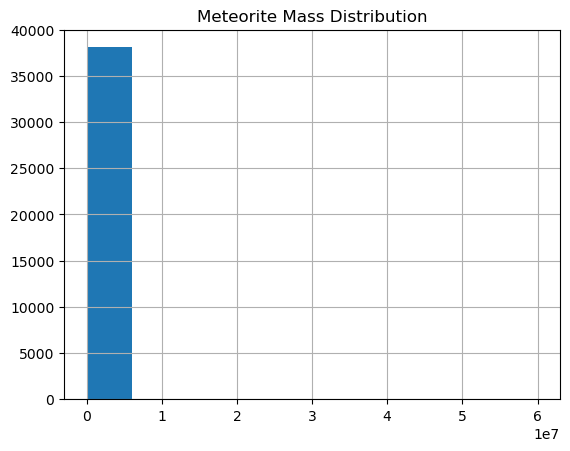

In [75]:
import matplotlib.pyplot as plt

df["mass (g)"].hist()
plt.title("Meteorite Mass Distribution")
plt.show()

In [76]:
df.groupby("century")["mass (g)"].agg(["mean", "median", "max"])

,mean,median,max
century,,,
20,15600.705542,29.09,60000000.0


In [77]:
df["fall"].value_counts()

fall
Found    37050
Fell      1065
Name: count, dtype: int64

In [78]:
import folium

m = folium.Map(location=[20, 0], zoom_start=2)

for i in df.head(500).index:
    folium.CircleMarker(
        location=[df.loc[i, "reclat"], df.loc[i, "reclong"]],
        radius=3,
        color="blue",
        fill=True
    ).add_to(m)

m

In [79]:
m.save("meteorite_map.html")


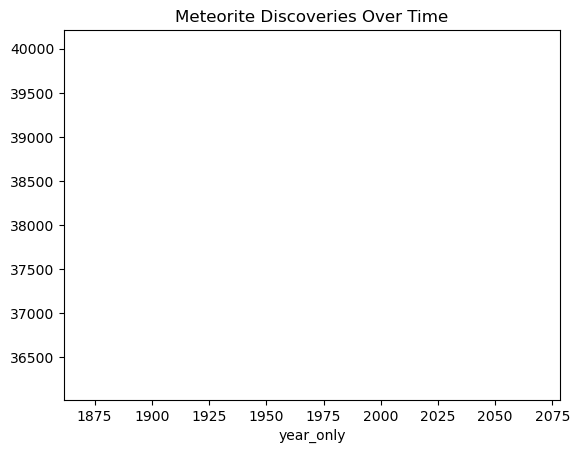

In [80]:
df["year_only"] = df["year"].dt.year

trend = df["year_only"].value_counts().sort_index()

trend.plot()
plt.title("Meteorite Discoveries Over Time")
plt.show()

In [81]:
import webbrowser
webbrowser.open("meteorite_map.html")

True

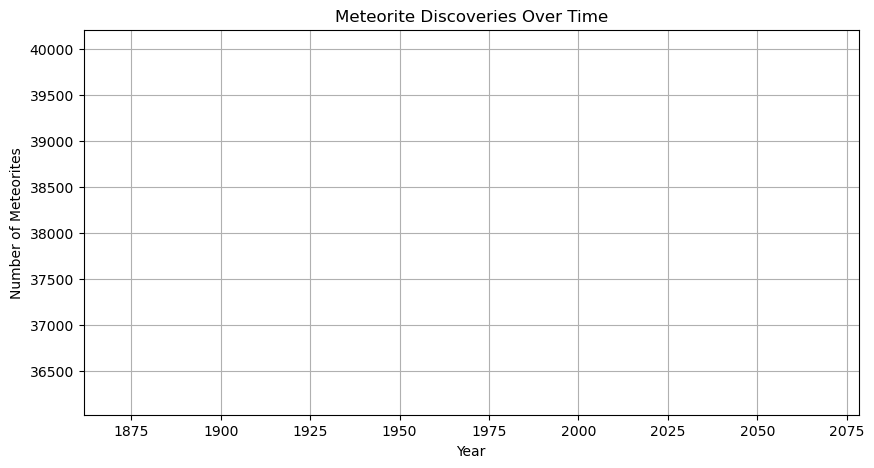

In [82]:
import matplotlib.pyplot as plt

trend.plot(figsize=(10,5))
plt.title("Meteorite Discoveries Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Meteorites")
plt.grid()
plt.show()

Observation:
The number of meteorite discoveries has increased over time. 
This may be due to advancements in technology and better tracking systems.

In [83]:
import folium

m = folium.Map(location=[20, 0], zoom_start=2)

for i in df.head(500).index:
    folium.CircleMarker(
        location=[df.loc[i, "reclat"], df.loc[i, "reclong"]],
        radius=3,
        color="blue",
        fill=True
    ).add_to(m)

m

In [61]:
m.save("meteorite_map.html")